# Supermarket Sales Data Visualization

## CodeAlpha Data Analytics Internship — Task 3

### Project Overview

This project transforms supermarket sales data into meaningful visualizations to communicate business insights clearly.

The analysis focuses on sales performance, product performance, branch performance, customer behavior, payment methods, and time-based sales patterns.

The objective is to create clear and informative visualizations that support data interpretation and decision-making.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [41]:
df = pd.read_csv("SuperMarket Analysis.csv")

In [42]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


Convert the dates and create the time variables:

In [43]:
df["Date"] = pd.to_datetime(df["Date"])

df["Time"] = pd.to_datetime(
    df["Time"],
    format="%I:%M:%S %p"
)

df["Hour"] = df["Time"].dt.hour
df["Day"] = df["Date"].dt.day_name()

In [44]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,Day
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,Saturday
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,Friday
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,Sunday
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,20,Sunday
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,10,Friday


# Visualization 1: Sales by Product Line

This directly answers:

**Which product lines contribute the most to total sales?**

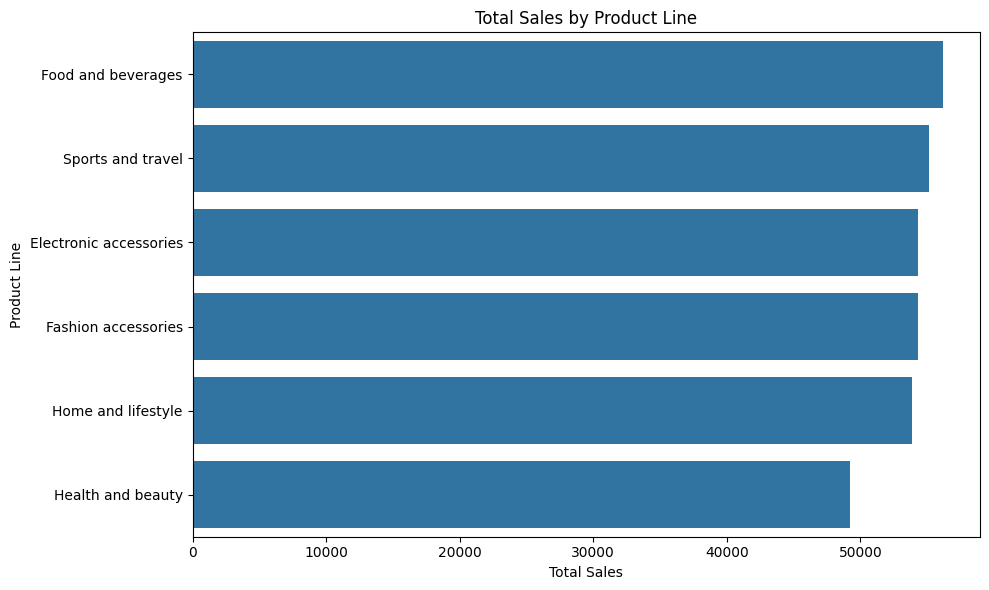

In [45]:
product_sales = (
    df.groupby("Product line")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title("Total Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.tight_layout()

plt.savefig(
    "sales_by_product_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 2: Sales by Branch

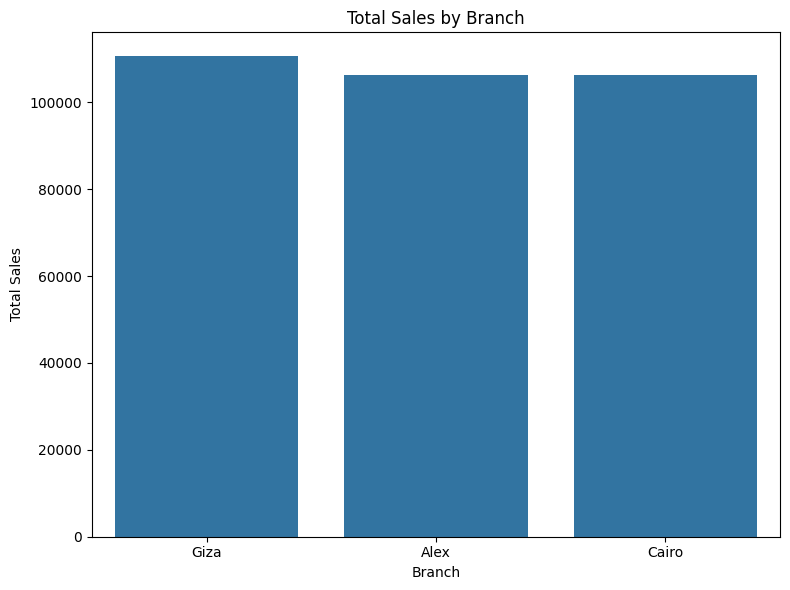

In [46]:
branch_sales = (
    df.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values
)

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    "sales_by_branch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 3: Payment Methods

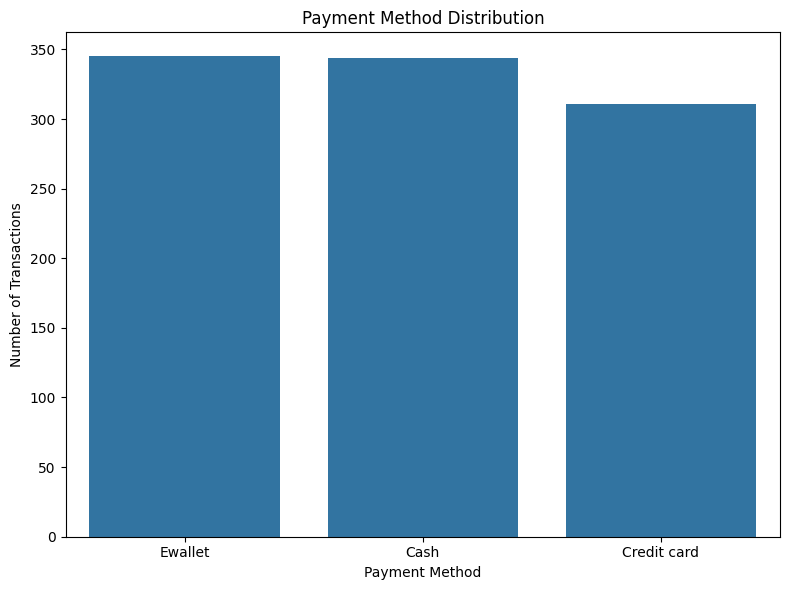

In [47]:
payment_counts = df["Payment"].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.savefig(
    "payment_methods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 4: Customer Type

Instead of only showing transaction counts, let's compare their average sales.

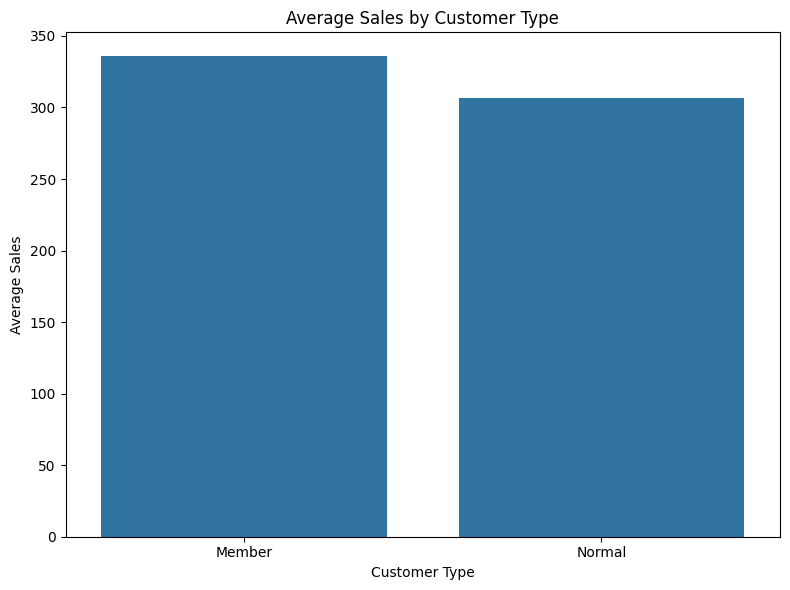

In [48]:
customer_avg_sales = (
    df.groupby("Customer type")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=customer_avg_sales.index,
    y=customer_avg_sales.values
)

plt.title("Average Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")
plt.tight_layout()

plt.savefig(
    "average_sales_customer_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 5: Quantity vs Sales

This is our relationship visualization.

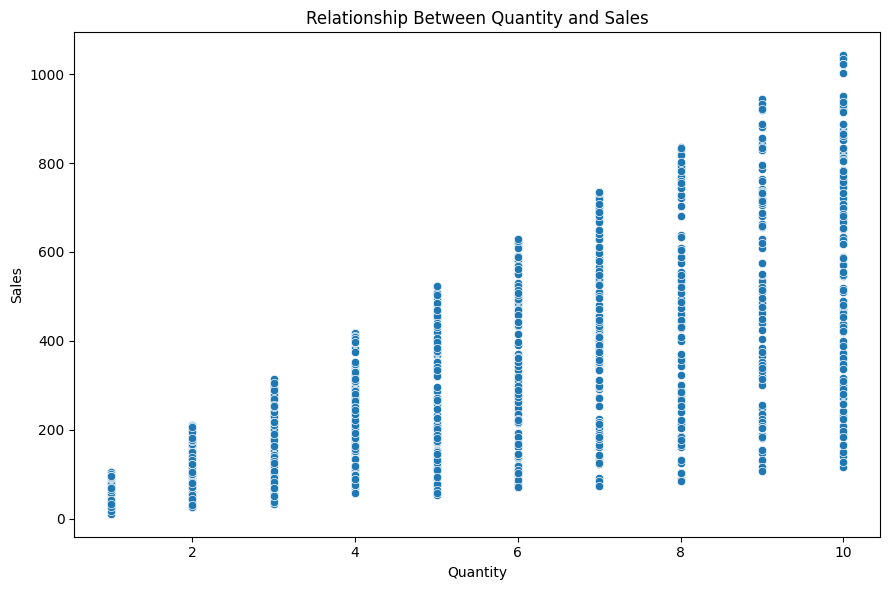

In [49]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales"
)

plt.title("Relationship Between Quantity and Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "quantity_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 6: Sales by Hour

This is one of the strongest visuals because it tells a time-based story.

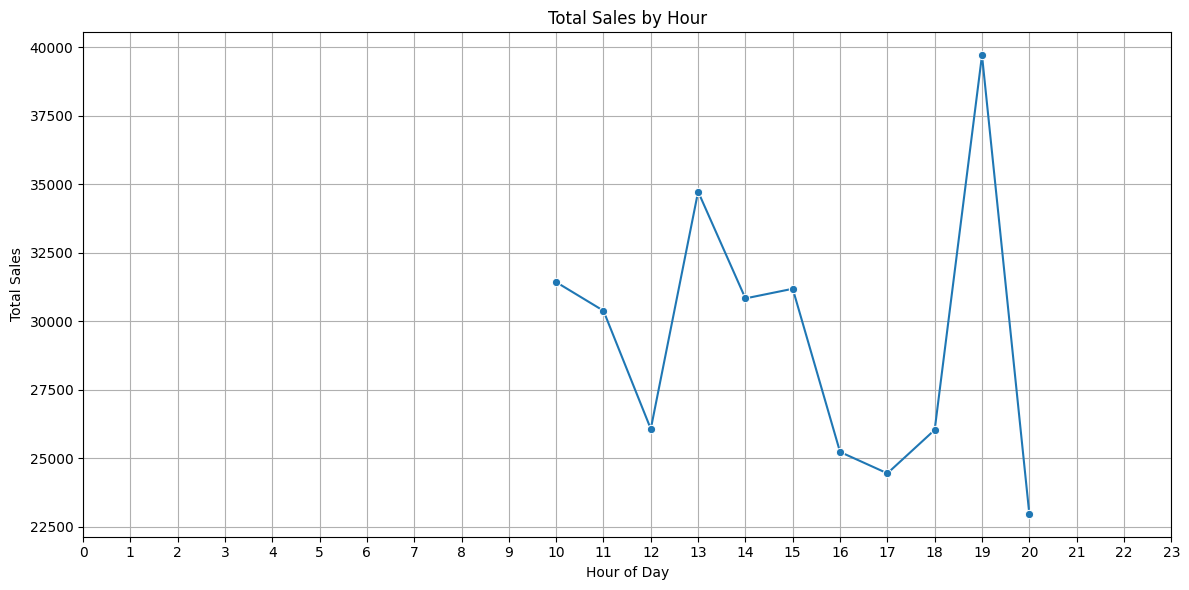

In [50]:
hourly_sales = (
    df.groupby("Hour")["Sales"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    marker="o"
)

plt.title("Total Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0, 24))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "sales_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 7: Sales by Day

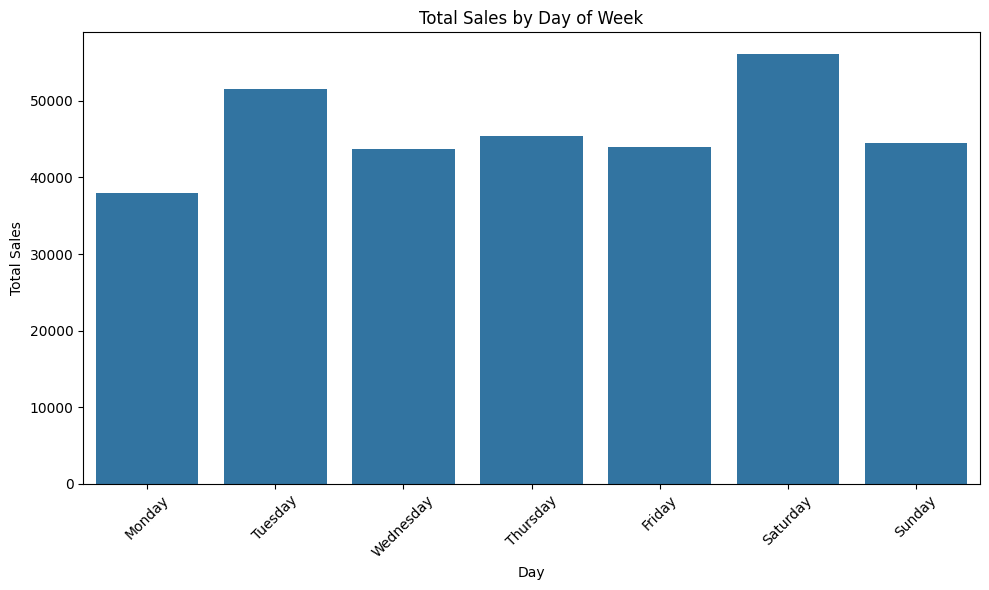

In [51]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_sales = (
    df.groupby("Day")["Sales"]
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=daily_sales.index,
    y=daily_sales.values
)

plt.title("Total Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "sales_by_day.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 8: Sales Distribution

Now show how transaction values are distributed.

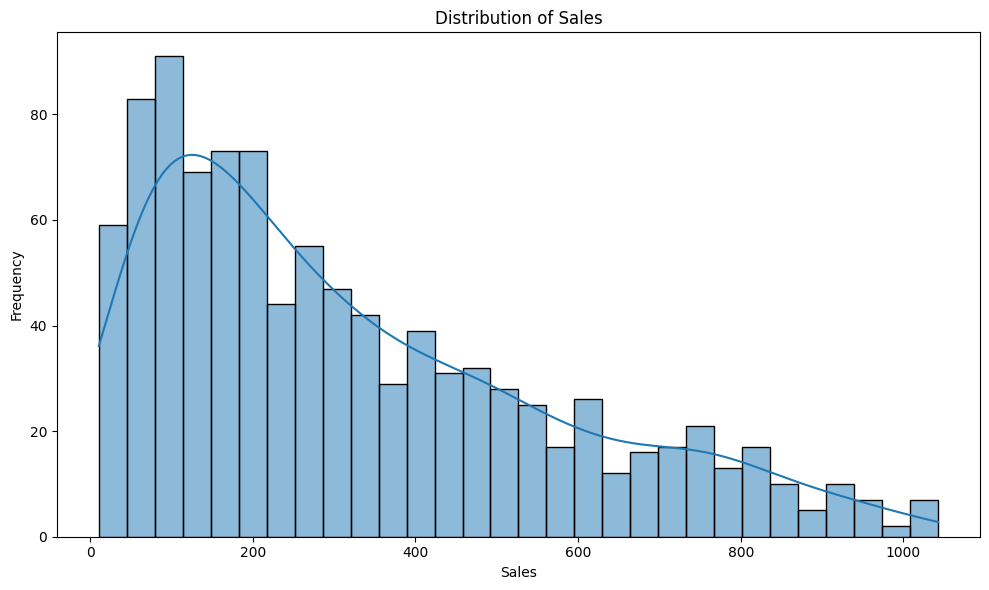

In [52]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 9: Outlier Analysis

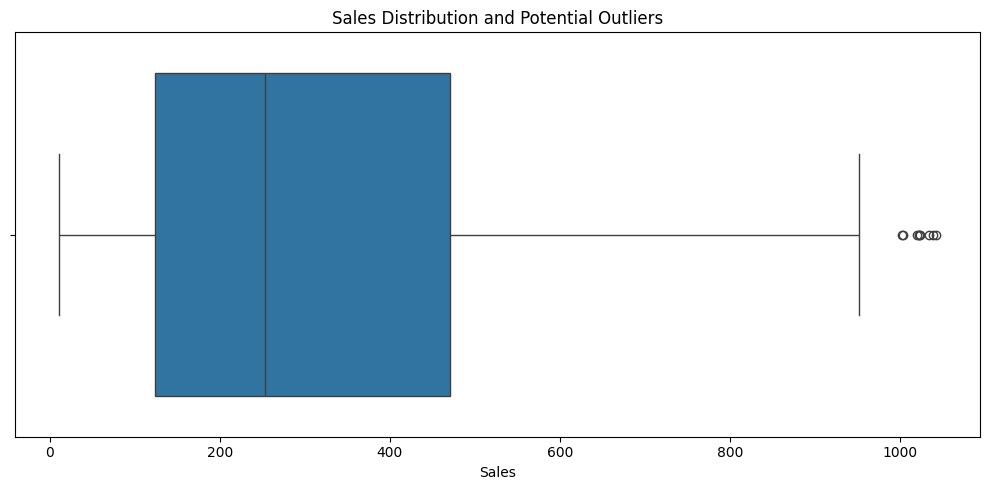

In [53]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Distribution and Potential Outliers")
plt.xlabel("Sales")

plt.tight_layout()

plt.savefig(
    "sales_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization 10: Correlation Heatmap

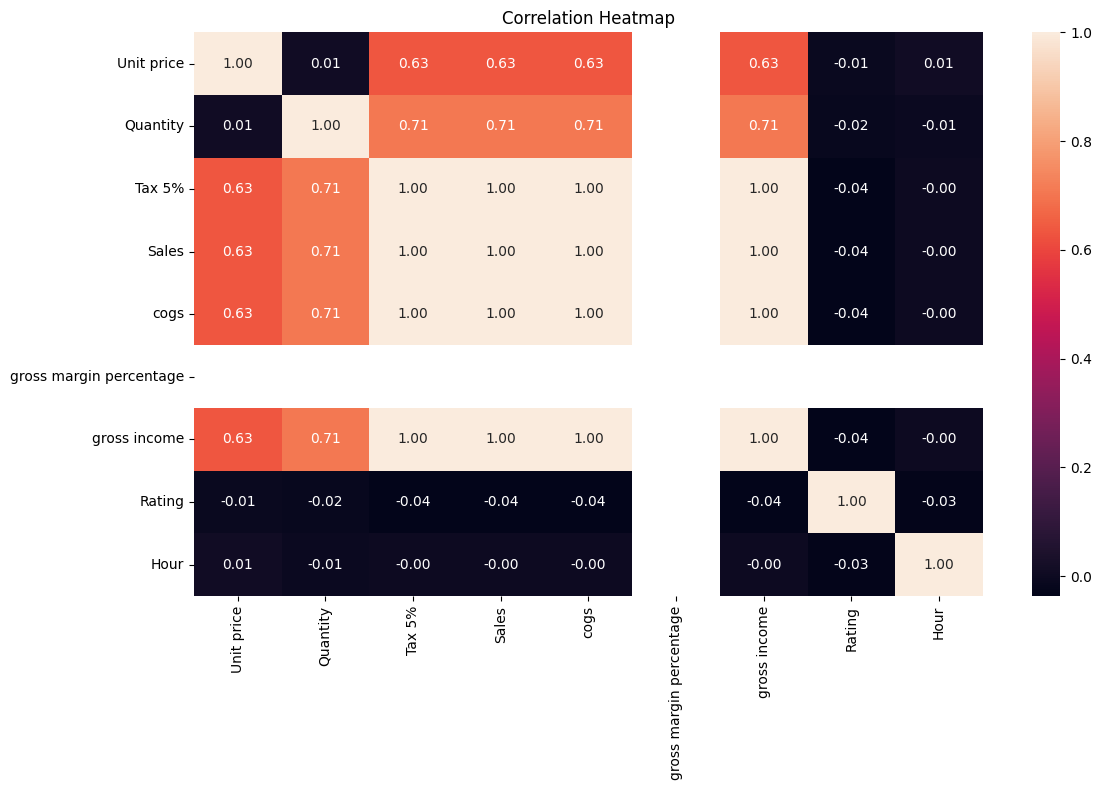

In [54]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Create a simple dashboard-style summary

/tmp/ipykernel_1391/4125019613.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.74])


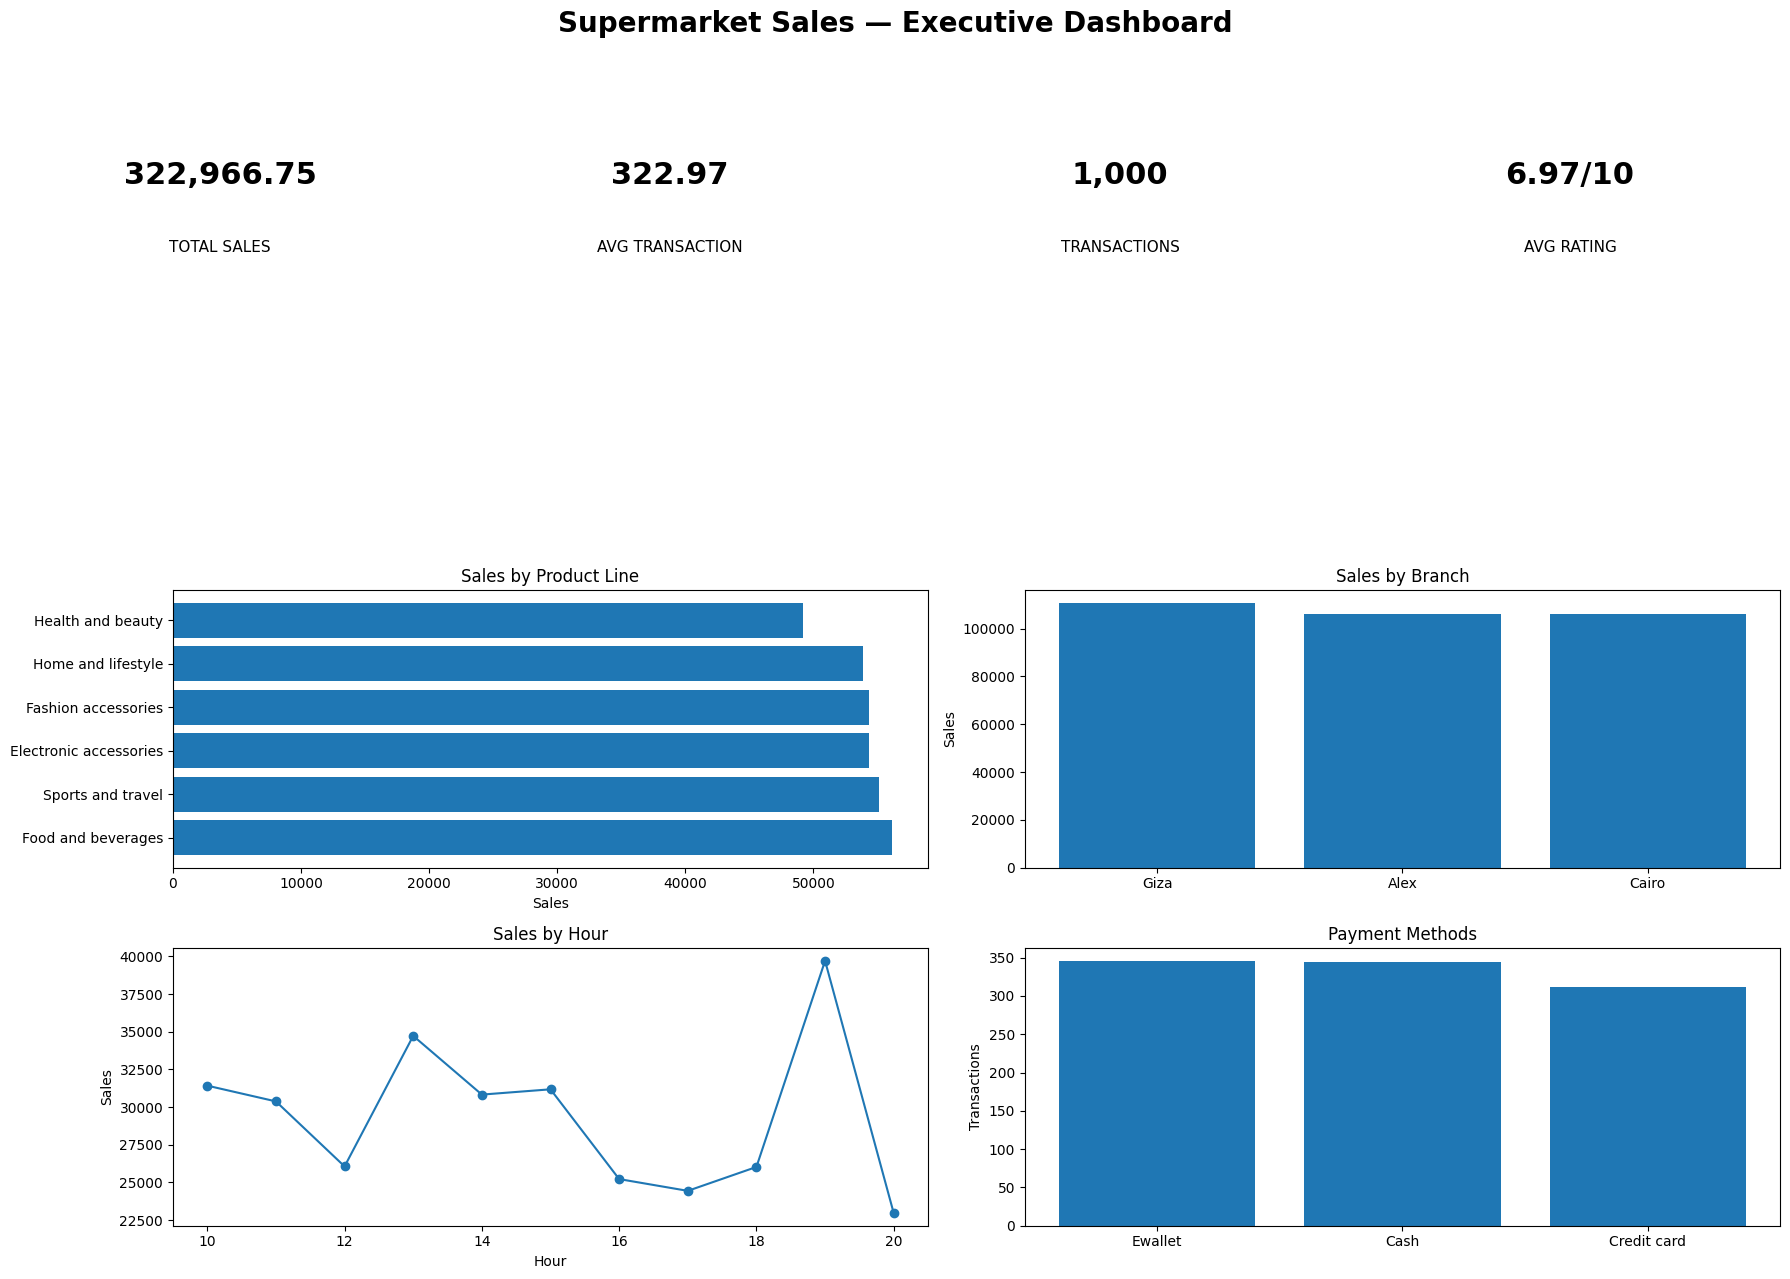

In [55]:
fig = plt.figure(figsize=(18, 13))

gs = fig.add_gridspec(
    3, 2,
    height_ratios=[0.7, 1.5, 1.5]
)

# KPI area
kpi_positions = [
    [0.02, 0.76, 0.21, 0.15],
    [0.27, 0.76, 0.21, 0.15],
    [0.52, 0.76, 0.21, 0.15],
    [0.77, 0.76, 0.21, 0.15]
]

kpis = [
    ("TOTAL SALES", f"{total_sales:,.2f}"),
    ("AVG TRANSACTION", f"{avg_transaction:,.2f}"),
    ("TRANSACTIONS", f"{total_transactions:,}"),
    ("AVG RATING", f"{avg_rating:.2f}/10")
]

for position, (label, value) in zip(kpi_positions, kpis):
    ax = fig.add_axes(position)
    ax.axis("off")

    ax.text(
        0.5, 0.62, value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25, label,
        ha="center",
        va="center",
        fontsize=11
    )

# Product
ax1 = fig.add_subplot(gs[1, 0])
ax1.barh(product_sales.index, product_sales.values)
ax1.set_title("Sales by Product Line")
ax1.set_xlabel("Sales")

# Branch
ax2 = fig.add_subplot(gs[1, 1])
ax2.bar(branch_sales.index, branch_sales.values)
ax2.set_title("Sales by Branch")
ax2.set_ylabel("Sales")

# Hour
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(hourly_sales.index, hourly_sales.values, marker="o")
ax3.set_title("Sales by Hour")
ax3.set_xlabel("Hour")
ax3.set_ylabel("Sales")

# Payment
ax4 = fig.add_subplot(gs[2, 1])
ax4.bar(payment_counts.index, payment_counts.values)
ax4.set_title("Payment Methods")
ax4.set_ylabel("Transactions")

plt.suptitle(
    "Supermarket Sales — Executive Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.74])

plt.savefig(
    "executive_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Advanced Visualization**

# **Sales Heatmap: Day × Hour**

This is more informative than having separate day and hour charts.

Question

When are the strongest sales periods throughout the week?

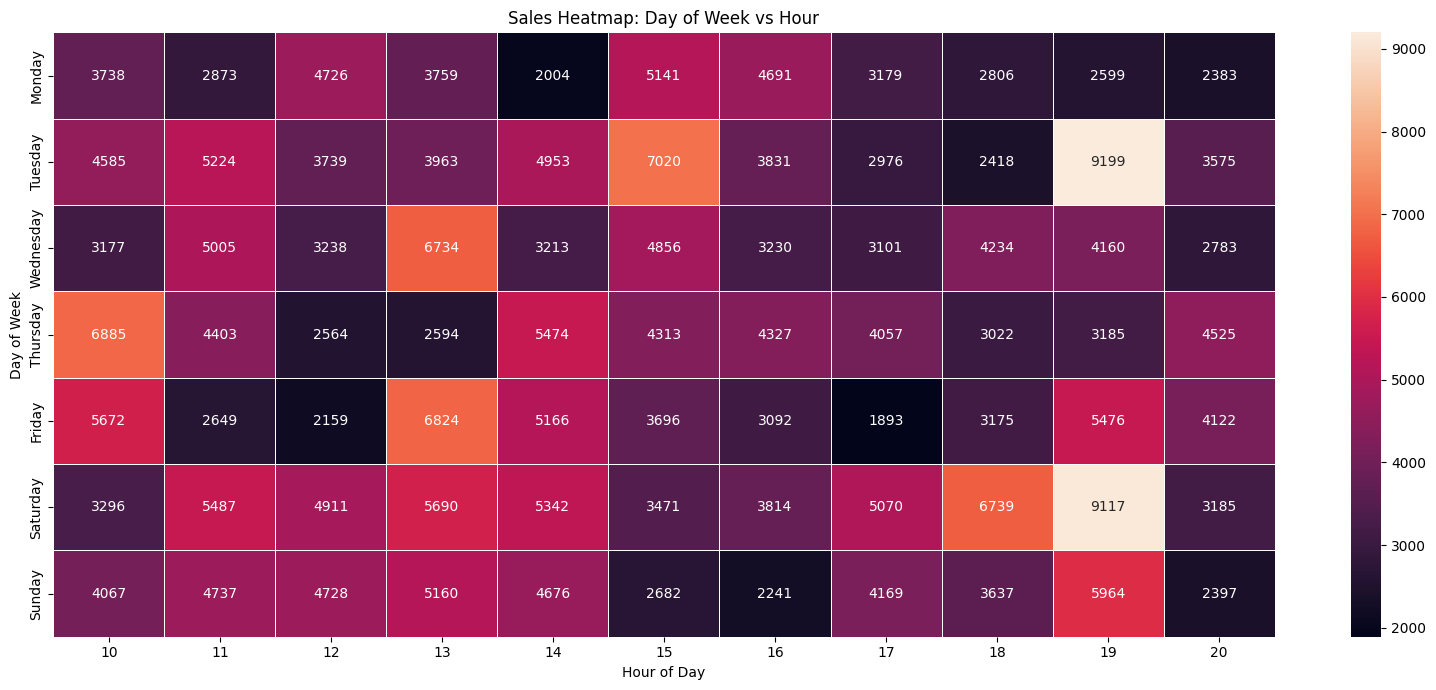

In [56]:
# Create ordered days
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Aggregate sales by day and hour
day_hour_sales = (
    df.groupby(["Day", "Hour"])["Sales"]
    .sum()
    .unstack(fill_value=0)
    .reindex(day_order)
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    day_hour_sales,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Sales Heatmap: Day of Week vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()

plt.savefig(
    "sales_day_hour_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Product × Branch Heatmap**
Question

**Which product lines perform strongly in which branches?**

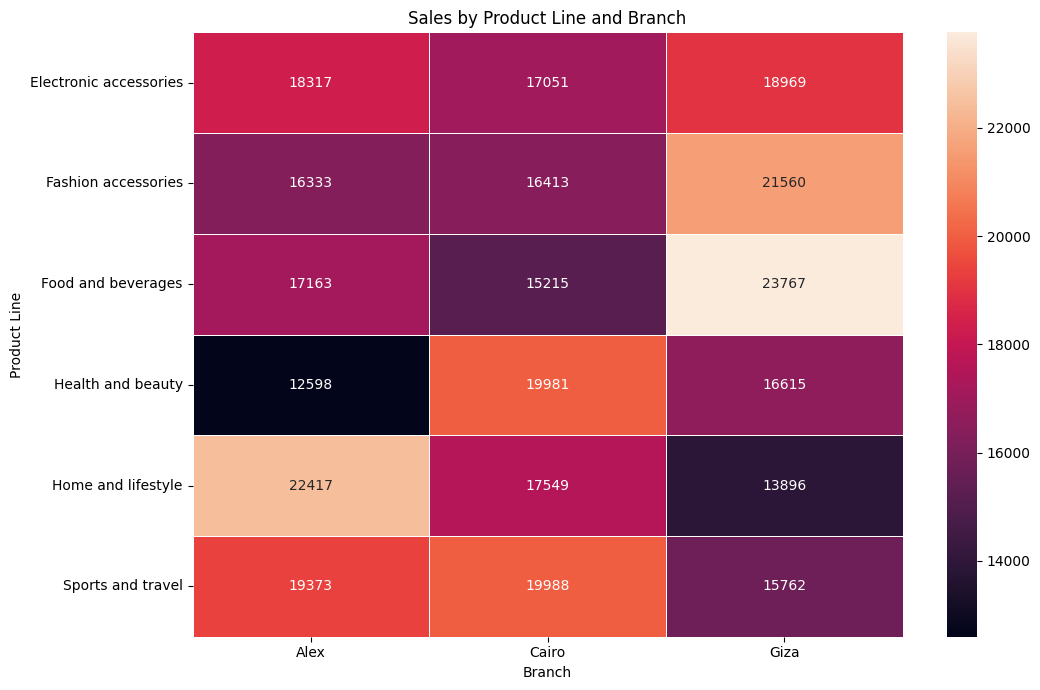

In [57]:
product_branch_sales = (
    df.groupby(["Product line", "Branch"])["Sales"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    product_branch_sales,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Sales by Product Line and Branch")
plt.xlabel("Branch")
plt.ylabel("Product Line")

plt.tight_layout()

plt.savefig(
    "product_branch_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Revenue Contribution**

Instead of only showing absolute sales, show each product line's percentage contribution.

In [58]:
product_contribution = (
    df.groupby("Product line")["Sales"]
    .sum()
)

product_contribution_pct = (
    product_contribution /
    product_contribution.sum() * 100
).sort_values(ascending=False)

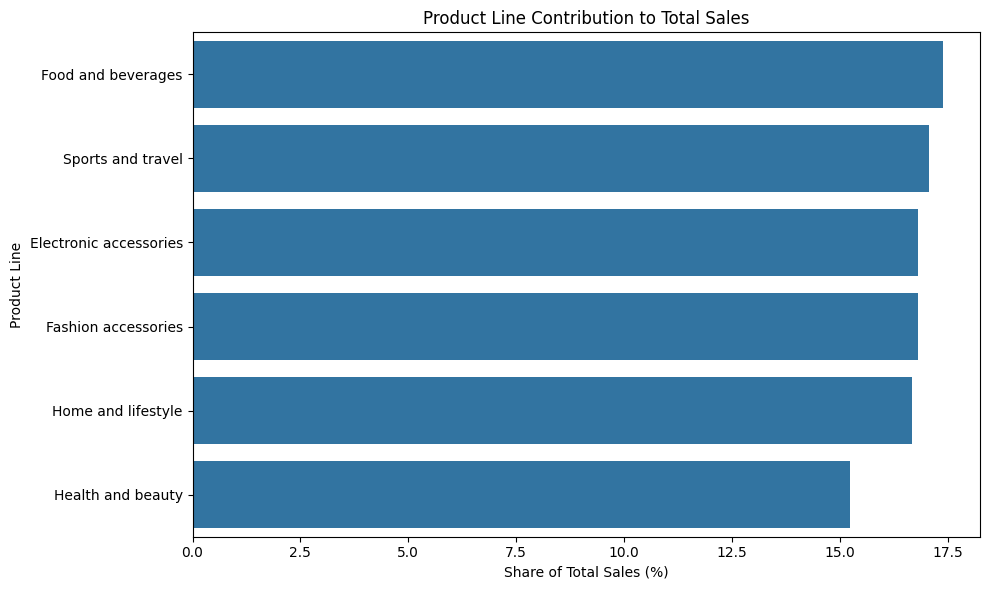

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_contribution_pct.values,
    y=product_contribution_pct.index
)

plt.title("Product Line Contribution to Total Sales")
plt.xlabel("Share of Total Sales (%)")
plt.ylabel("Product Line")

plt.tight_layout()

plt.savefig(
    "product_sales_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**answering:**

How much of total business revenue does each category contribute?

# **Sales Distribution by Product Line**

Let's investigate whether some product categories have more variable transaction values.

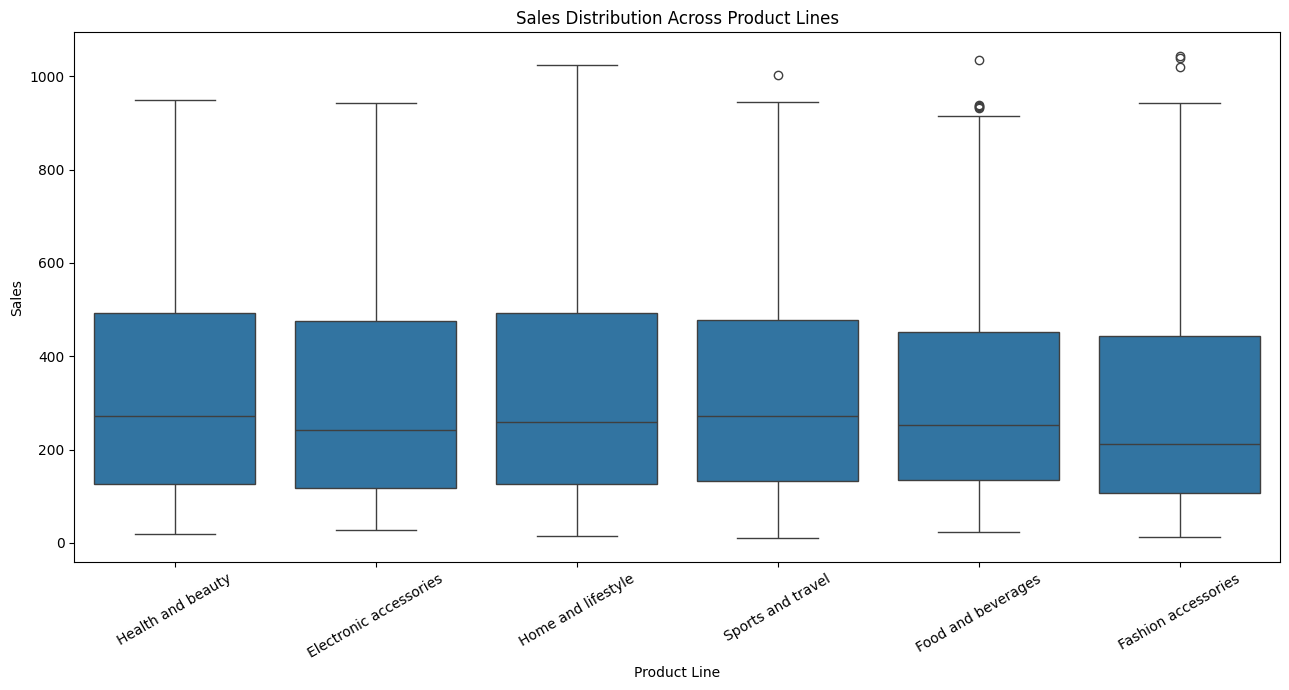

In [60]:
plt.figure(figsize=(13, 7))

sns.boxplot(
    data=df,
    x="Product line",
    y="Sales"
)

plt.title("Sales Distribution Across Product Lines")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "sales_distribution_product_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Customer Type × Product Line**

Now let's answer a deeper question:

Do Member and Normal customers behave differently across product categories?

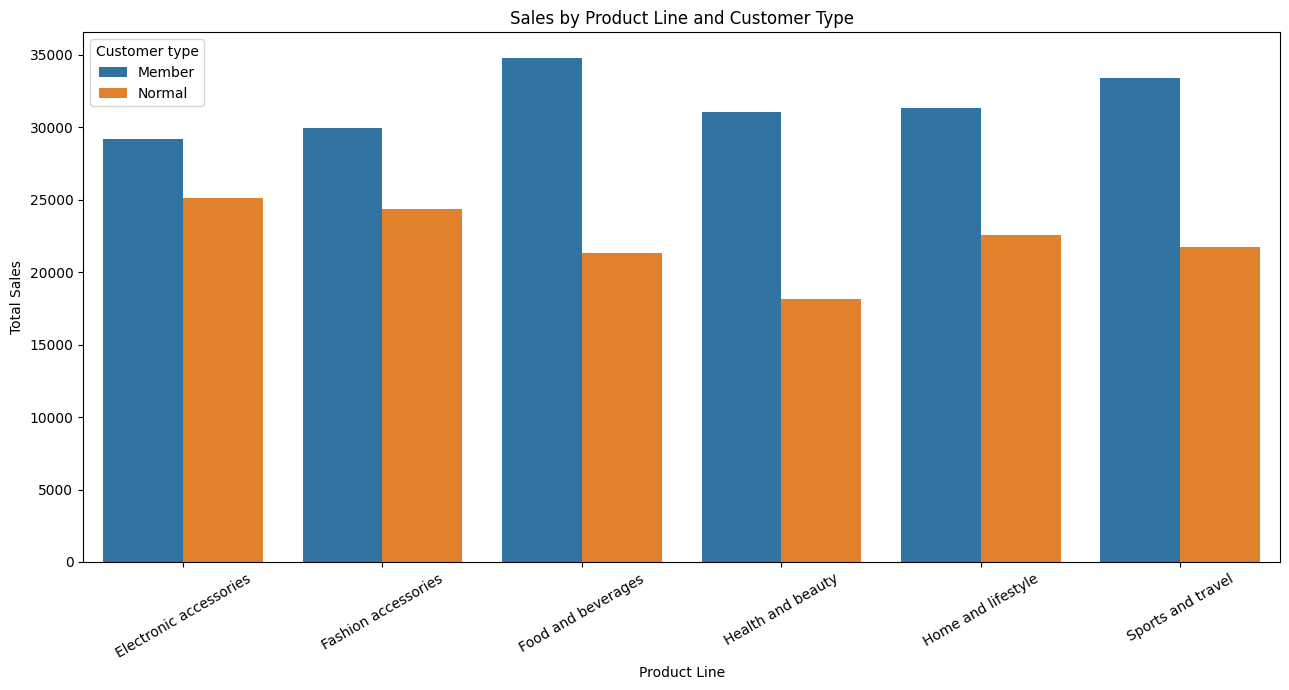

In [61]:
customer_product = (
    df.groupby(["Product line", "Customer type"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=customer_product,
    x="Product line",
    y="Sales",
    hue="Customer type"
)

plt.title("Sales by Product Line and Customer Type")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "product_customer_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# **Gender × Product Line**

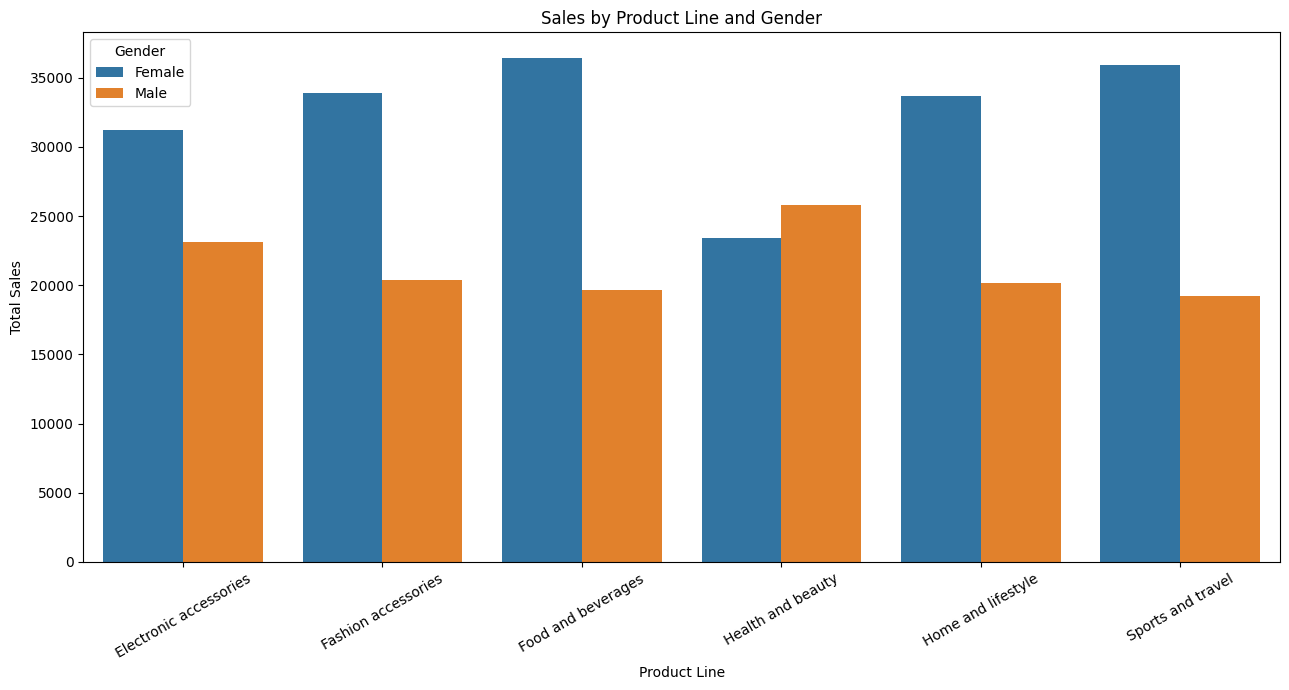

In [62]:
gender_product = (
    df.groupby(["Product line", "Gender"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=gender_product,
    x="Product line",
    y="Sales",
    hue="Gender"
)

plt.title("Sales by Product Line and Gender")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "product_gender_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Quantity vs Sales with Regression**

Your correlation was 0.706, so let's visualize the relationship together with a fitted regression line.

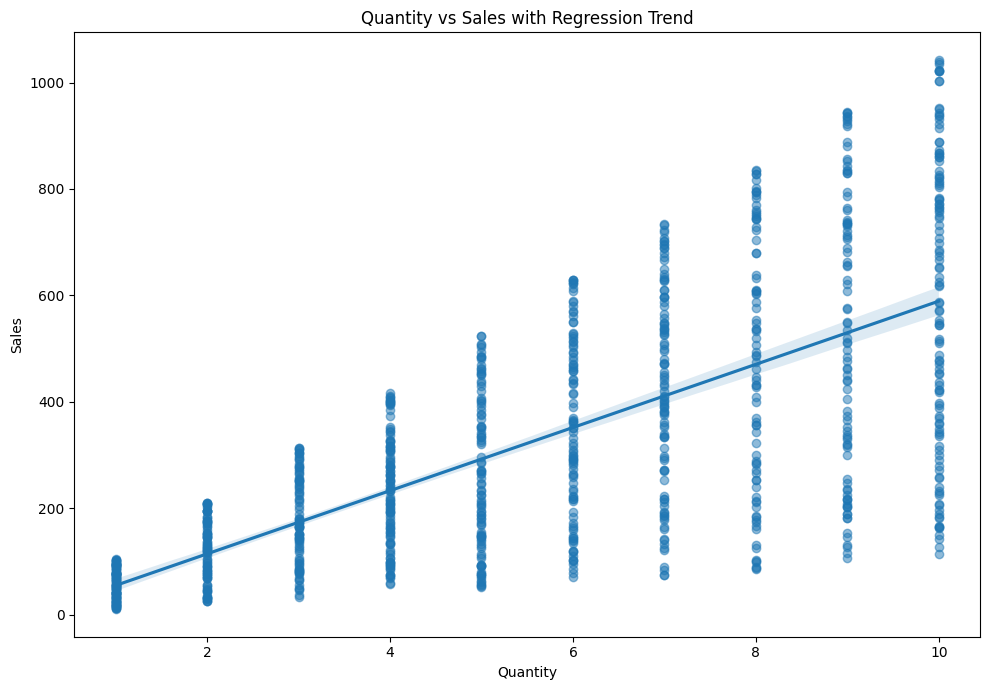

In [63]:
plt.figure(figsize=(10, 7))

sns.regplot(
    data=df,
    x="Quantity",
    y="Sales",
    scatter_kws={"alpha": 0.5},
    line_kws={}
)

plt.title("Quantity vs Sales with Regression Trend")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "quantity_sales_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Average Transaction Value by Hour**

Total sales can be affected by the number of transactions. Let's separate sales volume from average transaction value.

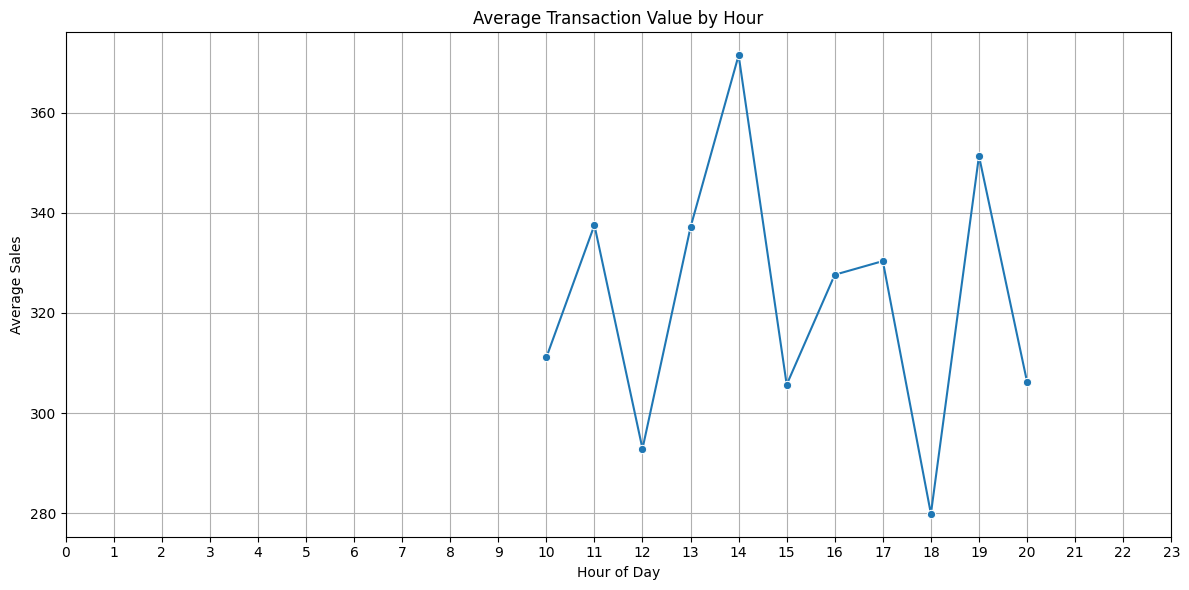

In [64]:
hourly_avg = (
    df.groupby("Hour")["Sales"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker="o"
)

plt.title("Average Transaction Value by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Sales")
plt.xticks(range(0, 24))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "average_transaction_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Sales vs Gross Income**

Because your dataset has both Sales and gross income, let's visualize their relationship.

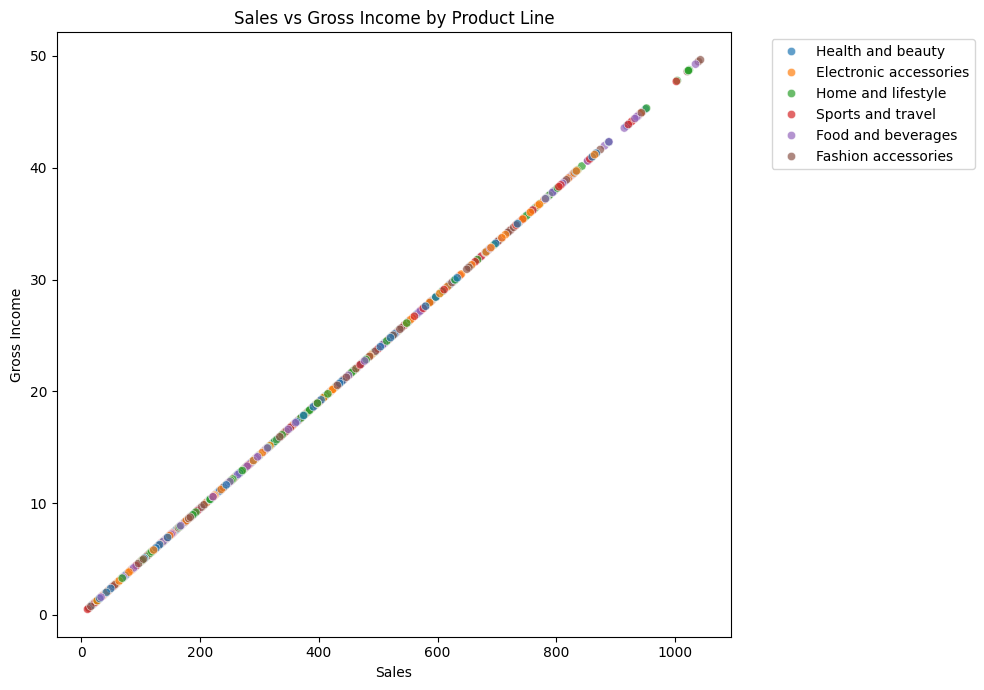

In [65]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Sales",
    y="gross income",
    hue="Product line",
    alpha=0.7
)

plt.title("Sales vs Gross Income by Product Line")
plt.xlabel("Sales")
plt.ylabel("Gross Income")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "sales_vs_gross_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Branch × Customer

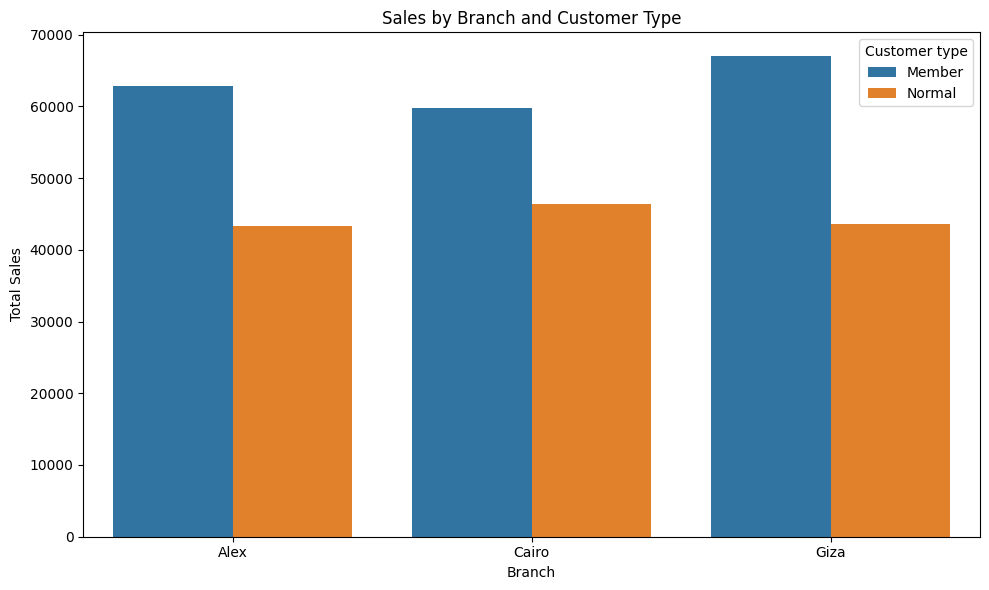

In [66]:
branch_customer = (
    df.groupby(["Branch", "Customer type"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=branch_customer,
    x="Branch",
    y="Sales",
    hue="Customer type"
)

plt.title("Sales by Branch and Customer Type")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "branch_customer_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Cumulative Sales Curve**

This shows how much of total sales comes from progressively larger transactions.

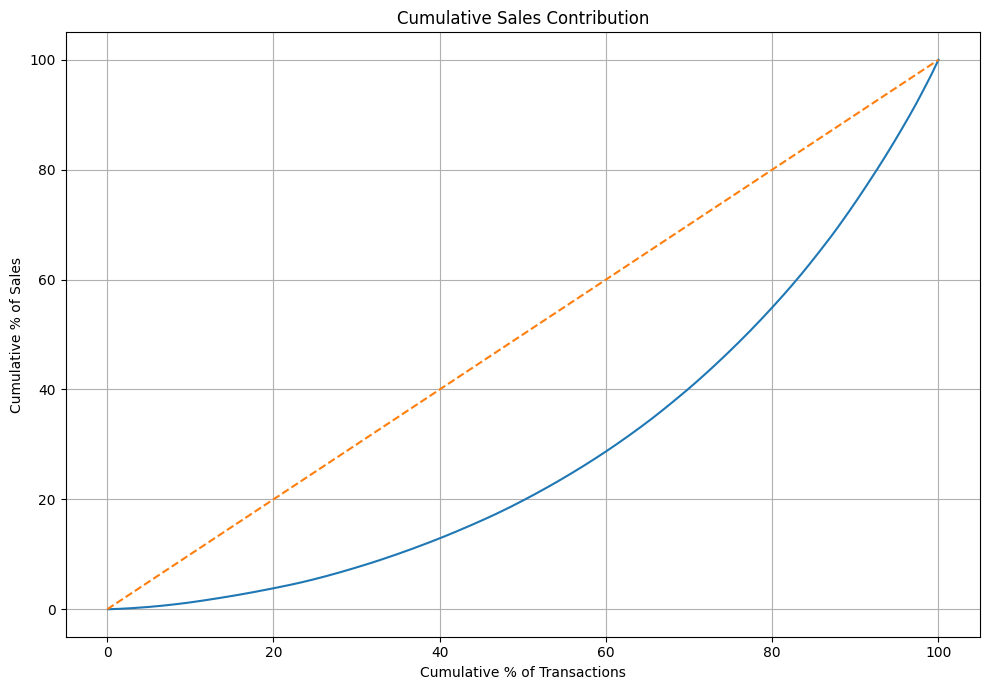

In [67]:
sorted_sales = np.sort(df["Sales"].values)

cumulative_sales = np.cumsum(sorted_sales)

percentage_transactions = (
    np.arange(1, len(sorted_sales) + 1)
    / len(sorted_sales)
) * 100

percentage_sales = (
    cumulative_sales /
    cumulative_sales[-1]
) * 100

plt.figure(figsize=(10, 7))

plt.plot(
    percentage_transactions,
    percentage_sales
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.title("Cumulative Sales Contribution")
plt.xlabel("Cumulative % of Transactions")
plt.ylabel("Cumulative % of Sales")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "cumulative_sales_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Visualization Insights**

### Product Performance

The product-line visualizations show differences in total sales and sales volume across categories. Food and beverages produced the highest total sales, while electronic accessories recorded the highest quantity sold.

### Branch Performance

The branch comparison shows that Giza recorded the highest total sales, while Alex and Cairo had very similar sales totals.

### Time-Based Performance

The day-hour heatmap provides a more detailed view of when sales occur. It combines two dimensions that cannot be fully understood from separate hourly and daily charts.

### Customer Behavior

Customer-segmentation visualizations show differences in transaction activity and sales behavior between Member and Normal customers.

### Payment Behavior

Payment-method visualization shows that E-wallet and cash were the two most frequently used payment methods.

### Sales Relationships

The regression visualization demonstrates the positive relationship between quantity and sales, while the correlation heatmap provides a broader view of relationships among numerical variables.

### Revenue and Profitability

The Sales versus Gross Income visualization demonstrates the relationship between transaction sales and gross income across product lines.

### Distribution and Anomalies

Box plots and distribution charts highlight variation in transaction values and identify observations that may warrant further investigation.

### Overall Data Story

The visualizations demonstrate that supermarket performance cannot be explained by a single metric. Product category, branch, customer segment, payment method, transaction volume, and time all provide different perspectives on the same business activity.

Combining these perspectives creates a more complete and decision-oriented understanding of the sales data.
